In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.base import BaseEstimator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l1
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split

import shap
import matplotlib.pyplot as plt

/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [43]:
class KerasClassifier(BaseEstimator):
    def __init__(self):
        self.model = None

    def build_model(self, input_dim):
        model = Sequential()
        model.add(Dense(50, input_dim=input_dim, activation='relu', kernel_regularizer=l1(1e-5)))
        model.add(Dense(50, activation='relu', kernel_regularizer=l1(1e-5)))
        model.add(Dense(1, activation='sigmoid'))
        model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', 'AUC'])
        return model

    def fit(self, X, y):
        input_dim = X.shape[1]
        self.model = self.build_model(input_dim)
        early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
        self.model.fit(X, y, epochs=15, batch_size=128, verbose=0, callbacks=[early_stop])

    def predict(self, X, y_true=None):
        y_pred_prob = self.model.predict(X)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()

        # if y_true is not None:
            # # 建立 DataFrame 來看錯誤樣本
            # results = pd.DataFrame({
            #     'y_true': y_true,
            #     'y_pred': y_pred,
            #     'correct': (y_pred == y_true)
            # })
            # errors = results[results['correct'] == False]
            # self.error_report_ = errors  # 儲存起來給外部使用
            # print(f"⚠️ 預測錯誤的樣本數：{len(errors)}")
            # print(errors.head())  # 顯示前幾筆錯誤

        return y_pred
def train(df: pd.DataFrame):
    # 1. 讀取資料
    # df = df[df['score'] != 'group2']

    # 2. 特徵與目標分開
    X = df.drop(columns=['score'])  # 所有特徵欄位
    y = df['score']                 # 目標欄位，為文字類別（'group1', 'group3'）
    print(f"X's shape: {X.shape}, y's shape: {y.shape}")

    # 3. 使用 LabelEncoder 轉換文字類別為數字
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    # 4. 自動分辨數值與類別欄位
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"Categorical columns: {categorical_cols}")
    numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
    print(f"Numerical columns: {numerical_cols}")

    # 5. 建立前處理器：數值欄位標準化、類別欄位 One-Hot 編碼
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ],
        remainder='passthrough'
    )
    # 7. 創建 Pipeline，將 preprocessor 和模型結合
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('keras', KerasClassifier())  # 使用自定義的 KerasClassifier
    ])

    # 8. 使用 StratifiedKFold 進行 5 折交叉驗證
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 9. 進行交叉驗證
    cross_val_results = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

    # 10. 顯示交叉驗證結果
    print(f'5-Fold Cross Validation Results: {cross_val_results}')
    print(f'Mean Accuracy: {cross_val_results.mean():.4f}')
    print(f'Standard Deviation: {cross_val_results.std():.4f}')

    #8. 訓練模型
    pipeline.fit(X, y)

    # 9. 獲取轉換後的數據
    X_transformed = pipeline.named_steps['preprocessor'].transform(X)
    print(f"X_transformed's shape: {X_transformed.shape}")
    categorical_feature_names = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols)
    numerical_feature_names = numerical_cols
    feature_names = np.concatenate([numerical_feature_names, categorical_feature_names])

    # 10. 計算 SHAP 值
    # 使用 DeepExplainer，這樣它會適用於深度學習模型（如 Keras）
    explainer = shap.Explainer(pipeline.named_steps['keras'].model, X_transformed)
    # 1. 印出 explainer 整體概要
    print(explainer)
    print("Model    :", explainer.model)
    print("Masker   :", type(explainer.masker))
    print("Background stored in masker:", getattr(explainer.masker, 'data', None).shape)

    shap_values = explainer(X_transformed)
    shap.summary_plot(shap_values, X_transformed, feature_names=feature_names) 


X's shape: (2811, 24), y's shape: (2811,)
Categorical columns: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'module_presentation']
Numerical columns: ['studied_credits', 'late_ratio', 'completion_ratio', 'homepage_mean_click_interval', 'homepage_std_click_interval', 'homepage_mean_clicks', 'homepage_click_variance', 'input_mean_click_interval', 'input_std_click_interval', 'input_mean_clicks', 'input_click_variance', 'output_mean_click_interval', 'output_std_click_interval', 'output_mean_clicks', 'output_click_variance', 'early_score', 'late_score', 'mid_score']


/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


...

/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5-Fold Cross Validation Results: [0.87566607 0.88790036 0.86298932 0.85231317 0.87010676]
Mean Accuracy: 0.8698
Standard Deviation: 0.0120


/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


X_transformed's shape: (2811, 57)


PermutationExplainer explainer: 2812it [00:58, 39.85it/s]                          
/var/folders/_q/xfvw_6_d3c5b8t1lpm7rppnh0000gn/T/ipykernel_1642/1402931669.py:95: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)


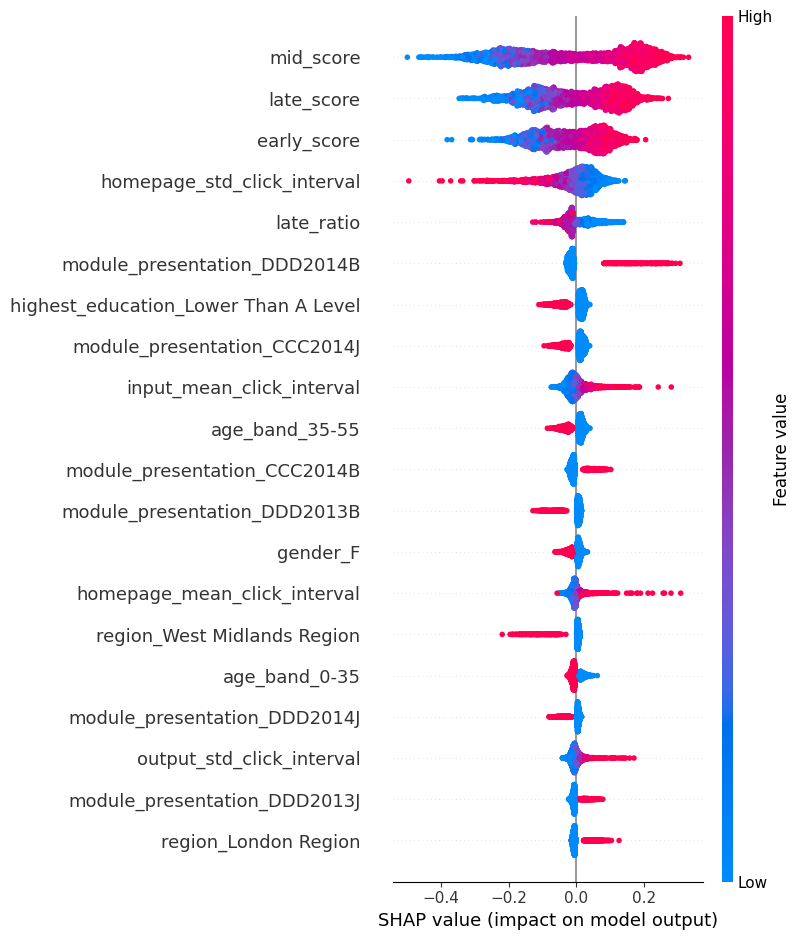

In [8]:
df = pd.read_csv('data_0521.csv')
df.drop(columns=['homepage_std_click_interval', 'output_std_click_interval', 'input_std_click_interval'], inplace=True)
# df_train = df[['score', 'gender', 'region', 'highest_education' ,'age_band' ,
#     'late_ratio' ,'homepage_mean_clicks' ,'homepage_mean_click_interval' ,#'homepage_std_click_interval' ,
#     'input_mean_clicks' ,#'input_std_click_interval' ,
#     'output_mean_click_interval' ,'output_mean_clicks' ,'output_click_variance' ,#'output_std_click_interval' ,
#     'early_score' ,'late_score' ,'mid_score', 'module_presentation']]
train(df)

In [44]:
df = pd.read_csv('data_0521.csv')
base_df = df[['score', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'module_presentation',]]
train(base_df)

X's shape: (2811, 6), y's shape: (2811,)
Categorical columns: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'module_presentation']
Numerical columns: []


/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


...

/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5-Fold Cross Validation Results: [0.6589698  0.61032028 0.61032028 0.64234875 0.63523132]
Mean Accuracy: 0.6314
Standard Deviation: 0.0189


/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


X_transformed's shape: (2811, 39)
shap.explainers.PermutationExplainer()
Model    : <shap.models._model.Model object at 0x3842090d0>
Masker   : <class 'shap.maskers._tabular.Independent'>
Background stored in masker: (100, 39)


DimensionError: The passed data does not match the background shape expected by the masker! The data of shape (1, 39) was passed while the masker expected data of shape (39,).

AttributeError: 'csr_matrix' object has no attribute 'head'

In [37]:
# 1. 讀取資料
# df = df[df['score'] != 'group2']

# 2. 特徵與目標分開
X = base_df.drop(columns=['score'])  # 所有特徵欄位
y = base_df['score']                 # 目標欄位，為文字類別（'group1', 'group3'）
print(f"X's shape: {X.shape}, y's shape: {y.shape}")

# 3. 使用 LabelEncoder 轉換文字類別為數字
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# 4. 自動分辨數值與類別欄位
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")
# numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
# print(f"Numerical columns: {numerical_cols}")

# 5. 建立前處理器：數值欄位標準化、類別欄位 One-Hot 編碼
preprocessor = ColumnTransformer(
    transformers=[
        # ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)
# 7. 創建 Pipeline，將 preprocessor 和模型結合
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('keras', KerasClassifier())  # 使用自定義的 KerasClassifier
])

#8. 訓練模型
pipeline.fit(X, y)

# 9. 獲取轉換後的數據
X_transformed = pipeline.named_steps['preprocessor'].transform(X)
print(f"X_transformed's shape: {X_transformed.shape}")
categorical_feature_names = pipeline.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_cols)

# 10. 計算 SHAP 值
# 使用 DeepExplainer，這樣它會適用於深度學習模型（如 Keras）
explainer = shap.Explainer(pipeline.named_steps['keras'].model, X_transformed)
shap_values = explainer(X_transformed)

shap.summary_plot(shap_values, X_transformed, feature_names=categorical_feature_names) 


X's shape: (2811, 6), y's shape: (2811,)
Categorical columns: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'module_presentation']


/Users/chiachishen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


X_transformed's shape: (2811, 39)


DimensionError: The passed data does not match the background shape expected by the masker! The data of shape (1, 39) was passed while the masker expected data of shape (39,).

In [38]:
print(type(explainer))
print(type(explainer.masker))

print("Explainer masker expected input shape:", getattr(explainer.masker, 'data', None).shape)


<class 'shap.explainers._permutation.PermutationExplainer'>
<class 'shap.maskers._tabular.Independent'>
Explainer masker expected input shape: (100, 39)


DimensionError: The passed data does not match the background shape expected by the masker! The data of shape (1, 39) was passed while the masker expected data of shape (39,).

# 3 class

In [ ]:
# 1. 讀取資料
df = pd.read_csv('data_0501_3c.csv')

# 2. 特徵與目標分開
X = df.drop(columns=['score'])  # 所有特徵欄位
y = df['score']                 # 目標欄位，為文字類別（'group1', 'group2', 'group3'）

# 3. 使用 LabelEncoder 轉換文字類別為數字
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # 將 'group1', 'group2', 'group3' 轉換為 0, 1, 2

# 4. 自動分辨數值與類別欄位
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

# 5. 建立前處理器：數值欄位標準化、類別欄位 One-Hot 編碼
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# 6. 定義 KerasClassifier 類別，並將 preprocessor 加入 Pipeline
class KerasClassifier(BaseEstimator):
    def __init__(self):
        self.model = Sequential()
        self.model.add(Dense(100, input_dim=None, activation='relu'))
        self.model.add(Dropout(0.2))
        self.model.add(Dense(50, activation='relu'))
        self.model.add(Dense(3, activation='softmax'))
        self.model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    def fit(self, X, y):
        # One-hot 編碼 y
        y_cat = to_categorical(y, num_classes=3)
        self.model.fit(X, y_cat, epochs=50, batch_size=32, verbose=0)

    def predict(self, X):
        y_pred_prob = self.model.predict(X)
        return np.argmax(y_pred_prob, axis=1)

# 7. 創建 Pipeline，將 preprocessor 和模型結合
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('keras', KerasClassifier())  # 使用自定義的 KerasClassifier
])

# 8. 使用 StratifiedKFold 進行 5 折交叉驗證
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 9. 進行交叉驗證
cross_val_results = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

# 10. 顯示交叉驗證結果
print(f'5-Fold Cross Validation Results: {cross_val_results}')
print(f'Mean Accuracy: {cross_val_results.mean():.4f}')
print(f'Standard Deviation: {cross_val_results.std():.4f}')


In [ ]:
import shap
import matplotlib.pyplot as plt

#8. 訓練模型
pipeline.fit(X, y)

# 9. 獲取轉換後的數據
X_transformed = pipeline.named_steps['preprocessor'].transform(X)
categorical_feature_names = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols)
numerical_feature_names = numerical_cols
feature_names = np.concatenate([numerical_feature_names, categorical_feature_names])

# 10. 計算 SHAP 值
# 使用 DeepExplainer，這樣它會適用於深度學習模型（如 Keras）
explainer = shap.Explainer(pipeline.named_steps['keras'].model, X_transformed)
shap_values = explainer(X_transformed)

# 提取 values 的三維 array
shap_array = shap_values.values  # shape = (samples, features, classes)

# 分類任務：為每一類別畫一張 summary_plot
n_classes = shap_array.shape[2]

for class_idx in range(n_classes):
    # 取得這個類別的 shap 值：取第 3 維的第 class_idx 個平面
    shap_per_class = shap_array[:, :, class_idx]  # shape = (samples, features)

    shap.summary_plot(
        shap_per_class,
        X_transformed,               # 注意這裡要對應經過編碼的特徵輸入
        feature_names=feature_names,
        show=False
    )
    plt.title(f'SHAP Summary Plot for Class {class_idx}')
    plt.show()